Séries Temporais
Problema de Negócio: Usando dados históricos das vendas ao longo de 2023, seria possível prever o total de vendas em Janeiro/2024?

In [1]:
# Versão da Linguagem Python
import sys
print('Versão da Linguagem Python Usada neste Jupyter Notebook:', sys.version)

Versão da Linguagem Python Usada neste Jupyter Notebook: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

Carregando os Dados

In [5]:
# Carrega o dataset
df = pd.read_csv(r'C:\Arquivos 2026\Curso_DSA_Data Science\sale\vendas_2023_completo.csv')

In [6]:
df.shape

(365, 2)

In [7]:
df.columns

Index(['Data', 'Total_Vendas'], dtype='str')

In [8]:
df.head()

,Data,Total_Vendas
0,2023-01-01,67.5483
1,2023-01-02,12.2510
2,2023-01-03,34.7526
3,2023-01-04,30.0889
4,2023-01-05,76.2823


In [9]:
df.tail()

,Data,Total_Vendas
360,2023-12-27,75.5690
361,2023-12-28,38.2309
362,2023-12-29,64.5587
363,2023-12-30,56.0280
364,2023-12-31,44.6676


Pré-Processamento dos Dados

In [10]:
# Valor Mínimo da coluna data
df['Data'].min()

'2023-01-01'

In [11]:
# Valor Máximo da coluna data
df['Data'].max()

'2023-12-31'

In [12]:
df.info()
# Como a data tem tracinhos - o pandas considera como string (str)
# Total_Vendas é a série temporal e Data é apenas a data que o evento ocoore (Data não é série temporal),então tem que fazer a conversão, porque o Pandas naõ sabe isso. O pandas não é a parte inteligente do processo, a parte inteligente é você

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Data          365 non-null    str    
 1   Total_Vendas  365 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


In [13]:
# Converte a coluna de data no tipo datetime
df['Data'] = pd.to_datetime(df['Data'])

In [14]:
df.head()

,Data,Total_Vendas
0,2023-01-01,67.5483
1,2023-01-02,12.2510
2,2023-01-03,34.7526
3,2023-01-04,30.0889
4,2023-01-05,76.2823


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Data          365 non-null    datetime64[us]
 1   Total_Vendas  365 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.8 KB


In [16]:
# Converter o DataFrame em uma série temporal com a data como índice
serie_temporal = df.set_index('Data')['Total_Vendas']

In [17]:
type(serie_temporal)

pandas.Series

In [18]:
serie_temporal
# Agora a data virou um indice

Data
2023-01-01    67.5483
2023-01-02    12.2510
2023-01-03    34.7526
2023-01-04    30.0889
2023-01-05    76.2823
               ...   
2023-12-27    75.5690
2023-12-28    38.2309
2023-12-29    64.5587
2023-12-30    56.0280
2023-12-31    44.6676
Name: Total_Vendas, Length: 365, dtype: float64

In [19]:
# Fornece a frequência da séria temporal (diária, neste caso). D = Diário
serie_temporal = serie_temporal.asfreq('D')

In [20]:
serie_temporal

Data
2023-01-01    67.5483
2023-01-02    12.2510
2023-01-03    34.7526
2023-01-04    30.0889
2023-01-05    76.2823
               ...   
2023-12-27    75.5690
2023-12-28    38.2309
2023-12-29    64.5587
2023-12-30    56.0280
2023-12-31    44.6676
Freq: D, Name: Total_Vendas, Length: 365, dtype: float64

Análise Exploratória

In [22]:
import os

os.makedirs('imagens', exist_ok=True)

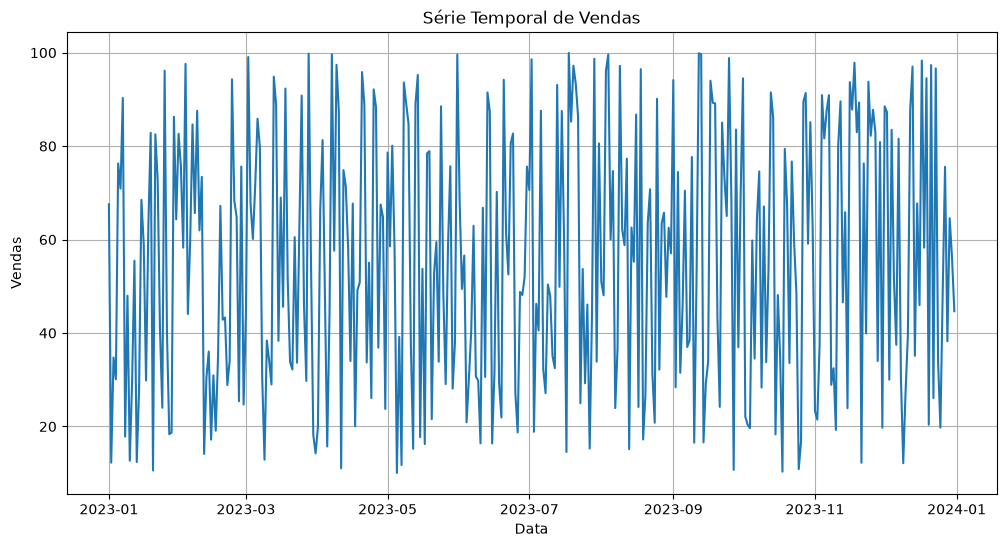

In [ ]:
# Cria o gráfico da série temporal (sem formatação). É um gráfico padrão
# A série temporal não é apenas a linha azul, é muito mais que isso, tem 4 componentes: sazonalidade, série, tendência e o ruído. Isso pode ser decomposto para entender melhor

plt.figure(figsize = (12, 6))
plt.plot(serie_temporal)
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.title('Série Temporal de Vendas')
plt.grid(True)

plt.savefig(
    'data_analysis/imagens/serie_temporal_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [24]:
import os

print(os.getcwd())
print(os.listdir())

c:\Arquivos 2026\Curso_DSA_Data Science\sale\data_analysis
['data.ipynb', 'imagens']


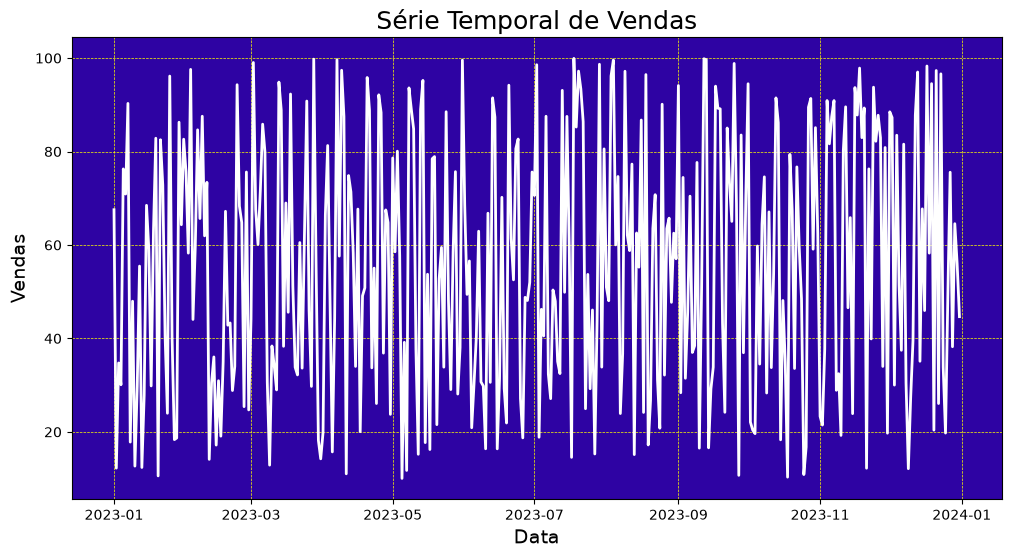

In [ ]:
# Cria o gráfico da série temporal (com formatação). Para relatórios

# Criar o gráfico da série temporal com layout de contraste
plt.figure(figsize = (12, 6))
plt.plot(serie_temporal, color = 'white', linewidth = 2)

# Configuras cores e estilo do gráfico
plt.gca().set_facecolor('#2e03a3')
plt.grid(color = 'yellow', linestyle = '--', linewidth = 0.5)

# Configurar rótulos dos eixos. título e legenda
plt.xlabel('Data', color = 'black', fontsize = 14)
plt.ylabel('Vendas', color = 'black', fontsize = 14)
plt.title('Série Temporal de Vendas', color = 'black', fontsize = 18)

# Configurar as cores dos eixos e dos ticks (marcadores)
plt.tick_params(axis = 'x', colors = 'black')
plt.tick_params(axis = 'y', colors = 'black')

plt.savefig(
    'data_analysis/imagens/serie_temporal_estilizada.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Suavização Exponencial

In [ ]:
# A suavização exponencial é uma técnica de análise e previsão de séries temporais que aplica médias ponderadas aos dados históricos, onde os pesos diminuem exponencialmente à medida que os dados ficam mais antigos. A suavização exponencial é útil para lidar com tendencias e sazonalidades nos dados, e para reduzir o ruído.

 # Suposições da Suavização Exponencial
https://www.statsmodels.org/stable/tsa.html#exponential-smoothing 

 # No Statsmodels, a classe SimpleExpSmoothing é uma implementação da técnica da suavização exponencial simples, que é uma versão básica da suavização exponencial que não lida explicitamente com tendências e sazonalidades
 # O modelo SimpleExpSmoothing do Statsmodels, também conhecido como suavização exponencila simples ou média móvel exponencialmente podenrada, é uma técnica de suavização de séries temporais que atribui pesos decrescentes exponencialmente aos pontos de dados passados. Ele é usado principalmente para suavizar séries temporais e fazer previsões de curto prazo. As principais suposições do modelo SimpleExpSmoothing são as seguintes:
 # - A série temporal é composta por um componente de nível (média) e um componente  de erro aleatório (ruído). Não há componentes de tendência ou sazonalidade na série.
 # - O componente de nível é uma média ponderada dos valores passados, com pesos que diminuem exponencialmente à medida que os dados ficam mais distantes no passado
 # - O componente do erro aleatório é normalmente distribuído com média zero e variância constante. Além disso, os erros são independentes e identicamente distribuídos.
 # - O parâmetro de suavização (alfa) é uma constante entre 0 e 1, que determina a taxa de decaimento dos pesos. Valores próximos a 1 dão maior peso aos dados mais recentes, enquanto valores próximos a 0 dão mais peso aos dados mais antigos.
 # O modelo SimpleExpSmoothing é uma técnica de suavização bastante simples que tem suas limitações. Ele é mais adequado para séries temporais que não apresentam tendências ou sazonalidades claras e para fazer previsões de curto prazo. Para séries temporais com componentes de tendência e/ou sazonalidade, modelos mais avançados como o ExponentialSmoothing de Holt-Winters ou modelos SARIMA podem ser mais apropriados.

Modelagem

In [27]:
# Cria o modelo
# Esta linha cria uma instância da classe SimpleExpSmoothing, utilizando a coluna 'Vendas' da série_temporal como entrada.

modelo = SimpleExpSmoothing(serie_temporal)

In [28]:
# Treinamento (ajuste) do modelo
# O valor 0.2 é uma experimentação, pode usar outros valores
# Esta linha faz uma chamada ao método fit() para ajustar o modelo de suavização exponencial aos dados. O argumento smoothing_level=0.2 define o parâmetro de suavização (alfa) como 0.2. O parâmetro de suavização controla a rapidez com que os pesos decrescem ao longo do tempo, um valor maior atribui mais peso aos dados mais recentes, enquanto um valor menor atribui mais peso aos dados mais antigos. O valor de alfa deve estar entre 0 e 1.

modelo_ajustado = modelo.fit(smoothing_level = 0.2)

c:\Arquivos 2026\Curso_DSA_Data Science\sale\venv\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [29]:
# Extrai os valores previstos pelo modelo
# Esta linha extrai os valores ajustados do modelo de suavização exponencial. Os valores ajustados são as estimativas da série temporal suavizada, que são calculadas aplicando os pesos exponenciais aos dados históricos. Esses valores ajustados podem ser usados para analisar a série temporal suavizada, identificar tend~encias e comparar com outras técnicas de suavização ou previsão.
# O resultado final é uma nova série temporal chamada suavização_exponencial, que representa a versão suavizada da série original de vendas, com menos ruído e flutuações de curto prazo.

suavizacao_exponencial = modelo_ajustado.fittedvalues

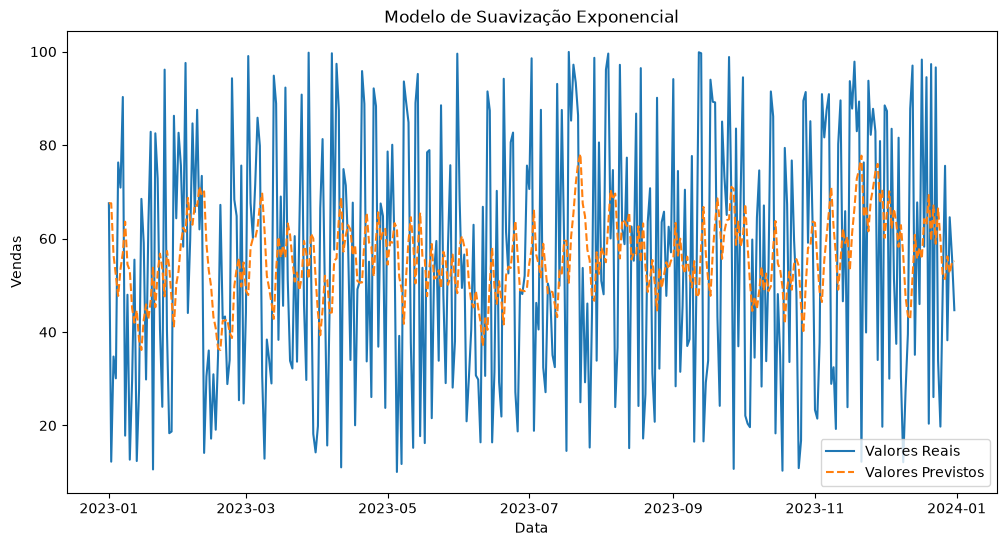

In [ ]:
# Plot
# O modelo não conseguiu acompanhar corretamente os dados reais, então teria que fazeroutro análise, outras transformações, observar sazonalidade para poder criar o modelo final.

plt.figure(figsize = (12,6))
plt.plot(serie_temporal, label = 'Valores Reais')
plt.plot(suavizacao_exponencial, label = 'Valores Previstos', linestyle = '--')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.title('Modelo de Suavização Exponencial')
plt.legend()

plt.savefig(
    'data_analysis/imagens/modelo_suavizacao_exponencial.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [31]:
import os

print(os.path.exists('imagens'))
print(os.listdir('imagens'))

True
['modelo_suavizacao_exponencial.png', 'serie_temporal_estilizada.png', 'serie_temporal_vendas.png']


Deploy e Previsão com o Modelo Treinado

In [27]:
# Fazer previsões
# Próximo dia para previsão 1/1/2024 (Um passo de previsão)

num_previsoes = 1
previsoes = modelo_ajustado.forecast(steps = num_previsoes)

In [29]:
print('Previsão do Total de Vendas para Janeiro/2024:',
      round(previsoes.values[0], 4))

Previsão do Total de Vendas para Janeiro/2024: 53.0879
